# 📊 Analysis After Processing — Cleaned Data (16 Stations)
**Mục tiêu:** Phân tích dữ liệu đã tiền xử lý:
1. Phân phối (distribution) của raw features và 8 engineered features mới
2. Tương quan (correlation) giữa các features — per station
3. So sánh cross-station

**Data:** `data/clean/clean_station_{id}.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.3})
sns.set_palette('tab10')

SELECTED_STATIONS = [1, 3, 4, 7, 9, 12, 13, 15, 16, 17, 18, 24, 27, 29, 31, 32]
CLEAN_DIR = 'data/clean'

RAW_POLL  = ['pm25', 'pm10', 'co', 'o3', 'no2', 'so2', 'aqi']
RAW_WTH   = ['temp', 'rh', 'dewpt', 'precip', 'clouds', 'wind_spd', 'wind_dir', 'wind_gusts']
RAW_SOIL  = ['soil_temp_0_7', 'soil_moist_0_7']
ENG_FEATS = ['oxidation_potential', 'pollution_load', 'no2_so2_ratio',
             'humid_sulfate_risk', 'dpd', 'thermal_stability',
             'stagnation_index', 'dust_source_potential']
ALL_NUM   = RAW_POLL + RAW_WTH + RAW_SOIL + ENG_FEATS

# Load all stations
station_dfs  = []
station_meta = []

print('Loading cleaned data...')
for sid in SELECTED_STATIONS:
    df = pd.read_csv(f'{CLEAN_DIR}/clean_station_{sid}.csv', parse_dates=['timestamp'])
    df = df.set_index('timestamp').sort_index()
    station_dfs.append(df)
    station_meta.append({
        'station_id': sid,
        'province'  : df['province'].iloc[0],
        'district'  : df['district'].iloc[0],
        'n_rows'    : len(df),
    })
    print(f'  OK Tram {sid:2d} | {df["province"].iloc[0]:12s} - {df["district"].iloc[0]:15s} | {len(df):,} rows')

_sid_to_idx = {m['station_id']: i for i, m in enumerate(station_meta)}
def get_df(sid): return station_dfs[_sid_to_idx[sid]]

all_df = pd.concat([df.reset_index() for df in station_dfs], ignore_index=True)
print(f'\nTotal: {len(all_df):,} rows | {len(all_df.columns)} columns')
display(all_df[ALL_NUM].describe().round(2))

Loading cleaned data...
  OK Tram  1 | Ha Noi       - Cau Giay        | 25,561 rows
  OK Tram  3 | Ha Noi       - Tay Ho          | 25,561 rows
  OK Tram  4 | Ha Noi       - Yen Lang        | 25,561 rows
  OK Tram  7 | TP.HCM       - Quan 1          | 25,561 rows
  OK Tram  9 | TP.HCM       - Quan Binh Thanh | 25,561 rows
  OK Tram 12 | TP.HCM       - Huyen Binh Chanh | 25,561 rows
  OK Tram 13 | Da Nang      - Thanh Khe       | 25,561 rows
  OK Tram 15 | Da Nang      - Lien Chieu      | 25,561 rows
  OK Tram 16 | Hai Phong    - Do Son          | 25,561 rows
  OK Tram 17 | Hai Phong    - Hong Bang       | 25,561 rows
  OK Tram 18 | Can Tho      - Ninh Kieu       | 25,561 rows
  OK Tram 24 | Dong Nai     - Bien Hoa        | 25,561 rows
  OK Tram 27 | Nam Dinh     - Nam Dinh        | 25,561 rows
  OK Tram 29 | Nghe An      - Nghe An         | 25,561 rows
  OK Tram 31 | Tra Vinh     - Tra Vinh        | 25,561 rows
  OK Tram 32 | An Giang     -  Rach Gia       | 25,561 rows

Total: 408,976

,pm25,pm10,co,o3,no2,so2,aqi,temp,rh,dewpt,...,soil_temp_0_7,soil_moist_0_7,oxidation_potential,pollution_load,no2_so2_ratio,humid_sulfate_risk,dpd,thermal_stability,stagnation_index,dust_source_potential
count,408976.00,408976.00,408976.00,408976.00,408976.00,408976.00,408976.00,408976.00,408976.00,408976.00,...,408976.00,408976.00,408976.00,408976.00,4.089760e+05,408976.00,408976.00,408976.00,408976.00,408976.00
mean,40.37,63.42,507.06,61.59,38.82,52.48,87.18,26.06,80.10,22.06,...,27.48,0.31,4268.19,598.36,2.404940e+03,4230.00,4.00,-1.43,0.34,1.92
std,121.14,152.59,1798.48,45.65,86.56,77.35,70.93,4.47,14.18,4.35,...,4.83,0.12,8069.38,1850.47,3.816416e+05,6536.09,3.36,1.57,0.14,1.12
min,0.00,0.00,0.00,0.00,0.00,0.00,4.00,6.50,21.00,-4.40,...,9.30,0.01,0.00,18.00,0.000000e+00,0.00,-0.10,-16.00,0.04,0.00
25%,10.00,21.00,72.20,26.00,4.00,12.00,50.00,24.20,72.00,20.60,...,25.30,0.23,740.00,101.70,1.800000e-01,927.00,1.40,-2.10,0.23,1.07
50%,18.67,34.00,109.70,58.90,11.00,28.00,69.00,26.30,83.00,23.70,...,27.60,0.34,1825.20,177.50,3.500000e-01,2184.00,3.10,-1.20,0.31,1.74
75%,33.00,55.00,202.00,88.70,31.00,66.00,102.00,28.90,92.00,24.80,...,30.20,0.41,4536.00,339.20,8.800000e-01,5201.00,5.50,-0.50,0.41,2.59
max,985.00,1231.30,15956.20,704.00,1310.00,1242.00,500.00,41.90,100.00,30.50,...,50.50,0.52,297756.00,16277.00,1.540000e+08,112866.60,26.30,6.90,1.00,18.46


---
## 1. Phân phối Raw Pollutants — Violin + Box (per province)

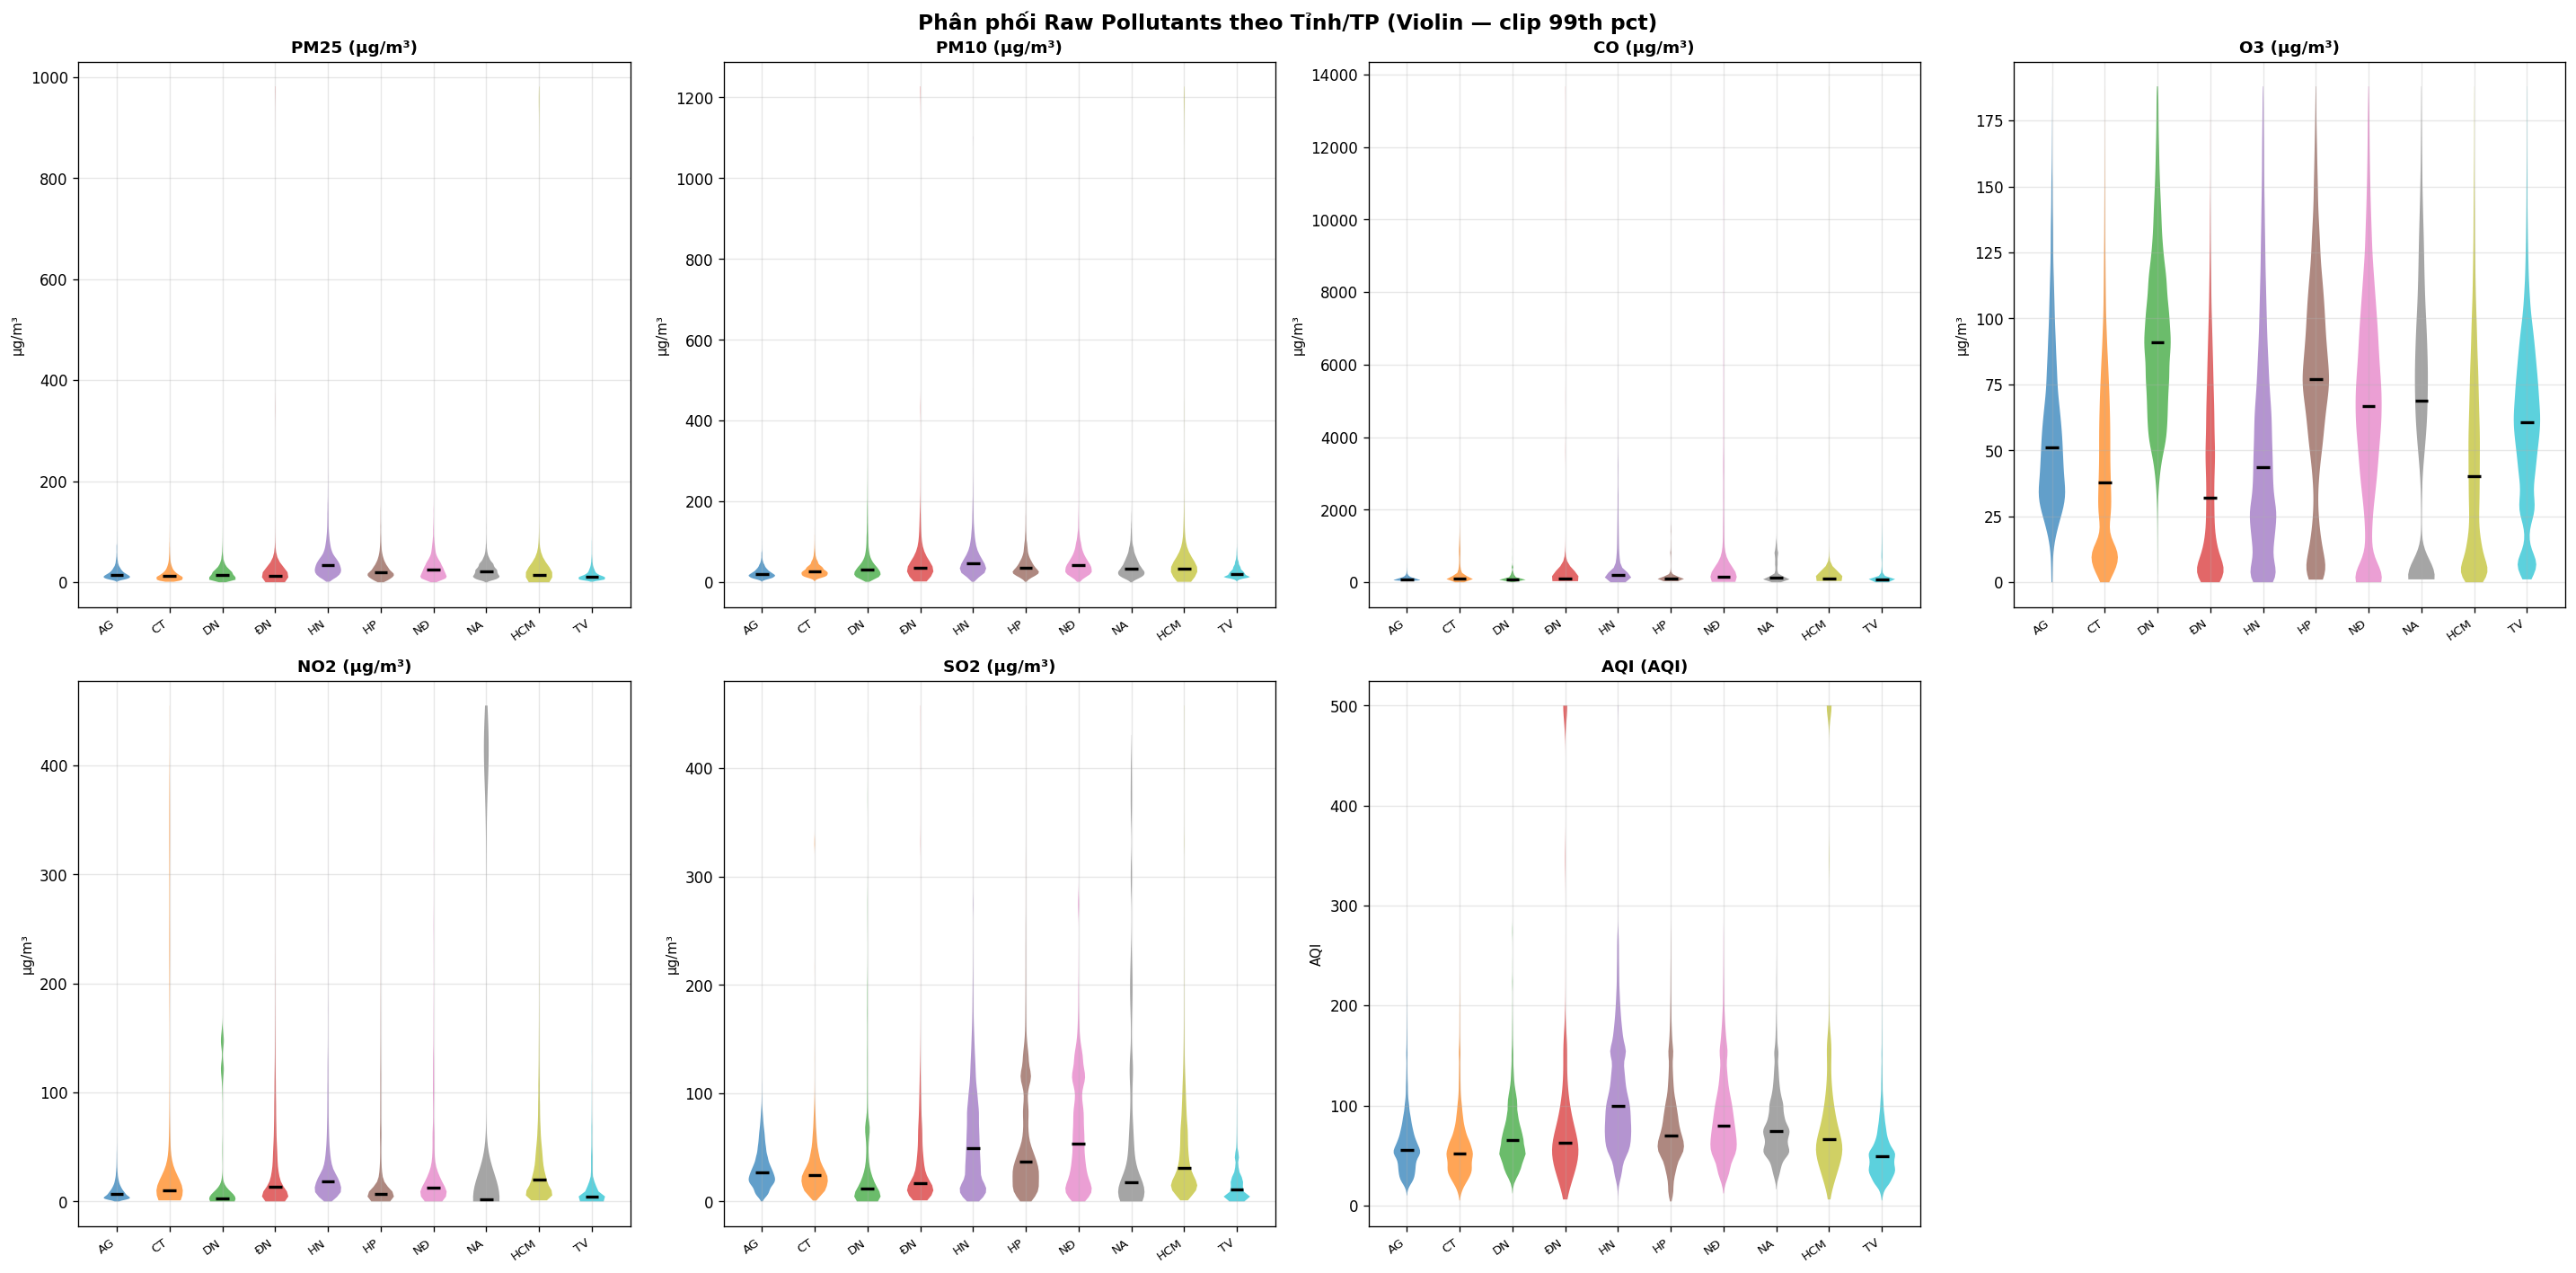

In [2]:
POLL_UNITS = {'pm25':'µg/m³','pm10':'µg/m³','co':'µg/m³',
              'o3':'µg/m³','no2':'µg/m³','so2':'µg/m³','aqi':'AQI'}

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for i, col in enumerate(RAW_POLL):
    ax = axes[i]
    data = all_df[['province', col]].dropna()
    # Clip cực đại để violin rõ ràng
    q99 = data[col].quantile(0.99)
    data = data[data[col] <= q99]

    provinces = sorted(data['province'].unique())
    colors = sns.color_palette('tab10', len(provinces))
    vals_list = [data[data['province'] == p][col].values for p in provinces]
    short_prov = [p.replace('TP.HCM','HCM').replace('Ha Noi','HN')
                   .replace('Da Nang','DN').replace('Hai Phong','HP')
                   .replace('Can Tho','CT').replace('Dong Nai','ĐN')
                   .replace('Nam Dinh','NĐ').replace('Nghe An','NA')
                   .replace('Tra Vinh','TV').replace('An Giang','AG') for p in provinces]

    vp = ax.violinplot(vals_list, positions=range(len(provinces)),
                       showmedians=True, showextrema=False)
    for j, (patch, color) in enumerate(zip(vp['bodies'], colors)):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    vp['cmedians'].set_color('black'); vp['cmedians'].set_linewidth(2)

    ax.set_xticks(range(len(provinces)))
    ax.set_xticklabels(short_prov, rotation=35, ha='right', fontsize=8)
    ax.set_title(f'{col.upper()} ({POLL_UNITS.get(col,"")})', fontsize=11, fontweight='bold')
    ax.set_ylabel(POLL_UNITS.get(col,''), fontsize=9)

axes[-1].set_visible(False)
fig.suptitle('Phân phối Raw Pollutants theo Tỉnh/TP (Violin — clip 99th pct)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dist_raw_pollutants_violin.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Phân phối Weather Features — KDE theo tỉnh

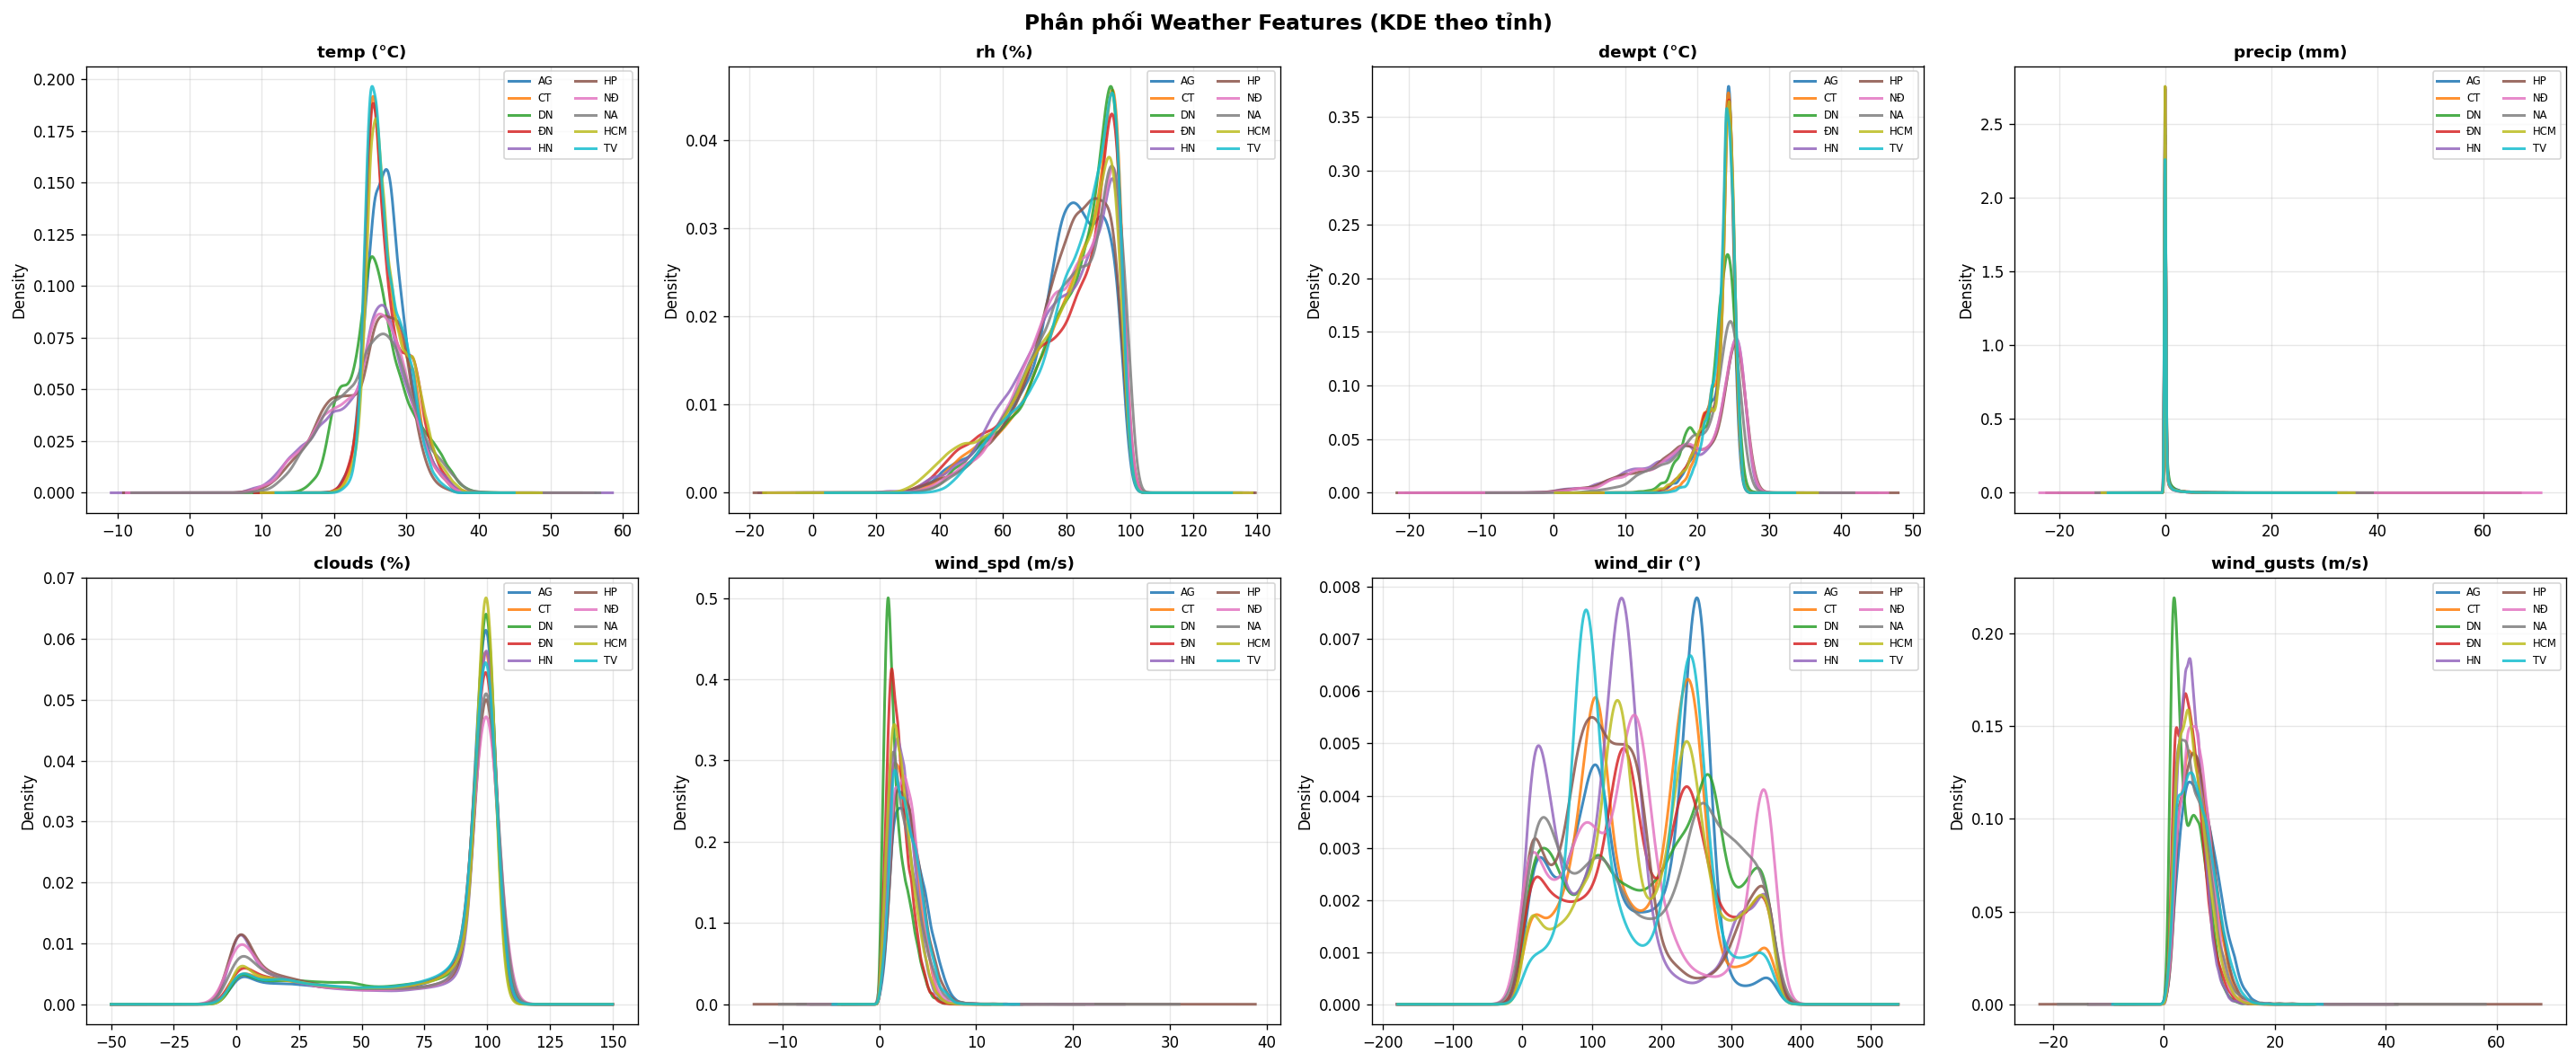

In [3]:
WTH_UNITS = {'temp':'°C','rh':'%','dewpt':'°C','precip':'mm',
             'clouds':'%','wind_spd':'m/s','wind_dir':'°','wind_gusts':'m/s'}

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes = axes.flatten()
provinces = sorted(all_df['province'].unique())
colors = sns.color_palette('tab10', len(provinces))
prov_abbr = {p: p.replace('TP.HCM','HCM').replace('Ha Noi','HN')
              .replace('Da Nang','DN').replace('Hai Phong','HP')
              .replace('Can Tho','CT').replace('Dong Nai','ĐN')
              .replace('Nam Dinh','NĐ').replace('Nghe An','NA')
              .replace('Tra Vinh','TV').replace('An Giang','AG') for p in provinces}

for i, col in enumerate(RAW_WTH):
    ax = axes[i]
    for prov, color in zip(provinces, colors):
        vals = all_df[all_df['province'] == prov][col].dropna()
        if len(vals) > 100:
            vals.plot.kde(ax=ax, label=prov_abbr[prov], color=color, lw=1.8, alpha=0.85)
    ax.set_title(f'{col} ({WTH_UNITS.get(col,"")})', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=7, ncol=2)

fig.suptitle('Phân phối Weather Features (KDE theo tỉnh)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dist_weather_kde.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Phân phối 8 Engineered Features — Histogram + KDE

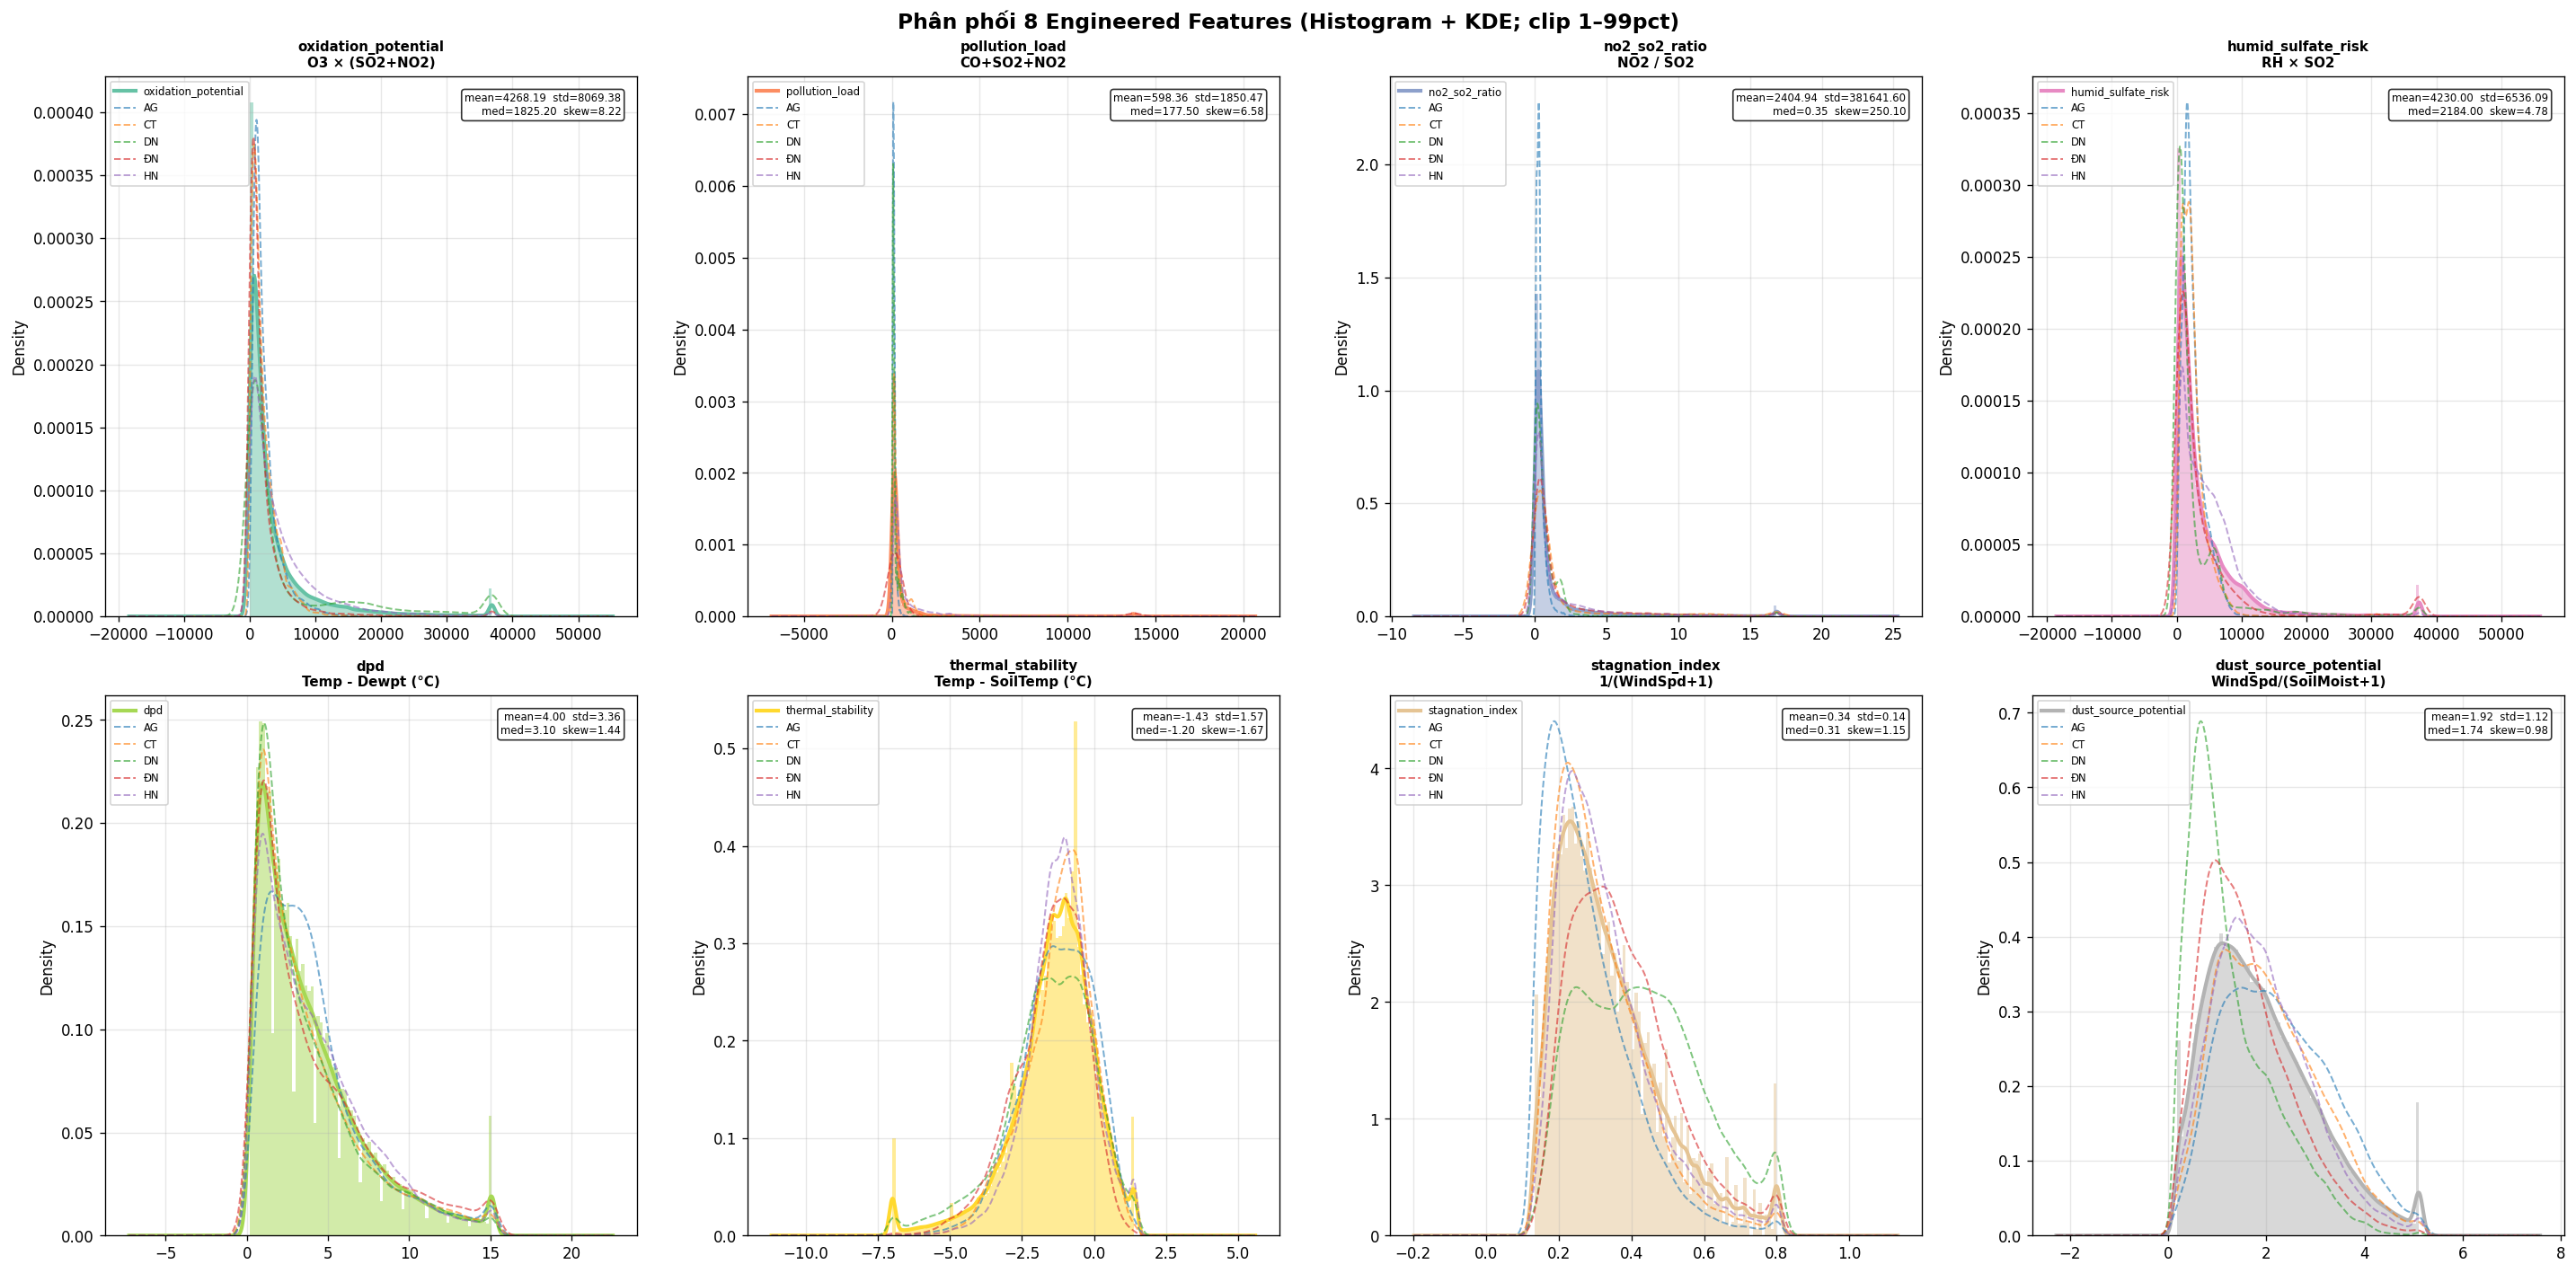

In [4]:
ENG_INFO = {
    'oxidation_potential' : 'O3 × (SO2+NO2)',
    'pollution_load'      : 'CO+SO2+NO2',
    'no2_so2_ratio'       : 'NO2 / SO2',
    'humid_sulfate_risk'  : 'RH × SO2',
    'dpd'                 : 'Temp - Dewpt (°C)',
    'thermal_stability'   : 'Temp - SoilTemp (°C)',
    'stagnation_index'    : '1/(WindSpd+1)',
    'dust_source_potential': 'WindSpd/(SoilMoist+1)',
}

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for i, (col, formula) in enumerate(ENG_INFO.items()):
    ax = axes[i]
    if col not in all_df.columns:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        continue

    vals = all_df[col].dropna()
    q1, q99 = vals.quantile(0.01), vals.quantile(0.99)
    vals_clipped = vals.clip(q1, q99)

    ax.hist(vals_clipped, bins=80, density=True, alpha=0.5,
            color=plt.cm.Set2(i/8), edgecolor='none')
    vals_clipped.plot.kde(ax=ax, color=plt.cm.Set2(i/8), lw=2.5)

    # Per-province overlay
    for prov, color in zip(provinces[:5], sns.color_palette('tab10', 5)):
        pvals = all_df[all_df['province'] == prov][col].dropna().clip(q1, q99)
        if len(pvals) > 100:
            pvals.plot.kde(ax=ax, color=color, lw=1.2, ls='--',
                           alpha=0.6, label=prov_abbr.get(prov, prov))

    # Thống kê
    ax.set_title(f'{col}\n{formula}', fontsize=9, fontweight='bold')
    stats_text = (f'mean={vals.mean():.2f}  std={vals.std():.2f}\n'
                  f'med={vals.median():.2f}  skew={vals.skew():.2f}')
    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=7,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.legend(fontsize=7)

fig.suptitle('Phân phối 8 Engineered Features (Histogram + KDE; clip 1–99pct)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dist_engineered_features.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Quality Flags — Frozen / Outlier / Sensor Error theo trạm

,frozen,outlier,pm25_sensor_error,total_rows
Station,,,,
1-Cau Giay,396 (1.5%),2556 (10.0%),83 (0.3%),25561
3-Tay Ho,344 (1.3%),2568 (10.0%),72 (0.3%),25561
4-Yen Lang,1042 (4.1%),4196 (16.4%),20 (0.1%),25561
7-Quan 1,2525 (9.9%),4936 (19.3%),1136 (4.4%),25561
9-Quan Binh Thanh,2531 (9.9%),4914 (19.2%),1117 (4.4%),25561
12-Huyen Binh Chanh,2234 (8.7%),4477 (17.5%),1238 (4.8%),25561
13-Thanh Khe,1481 (5.8%),6636 (26.0%),106 (0.4%),25561
15-Lien Chieu,2417 (9.5%),6754 (26.4%),123 (0.5%),25561
16-Do Son,1491 (5.8%),4961 (19.4%),280 (1.1%),25561


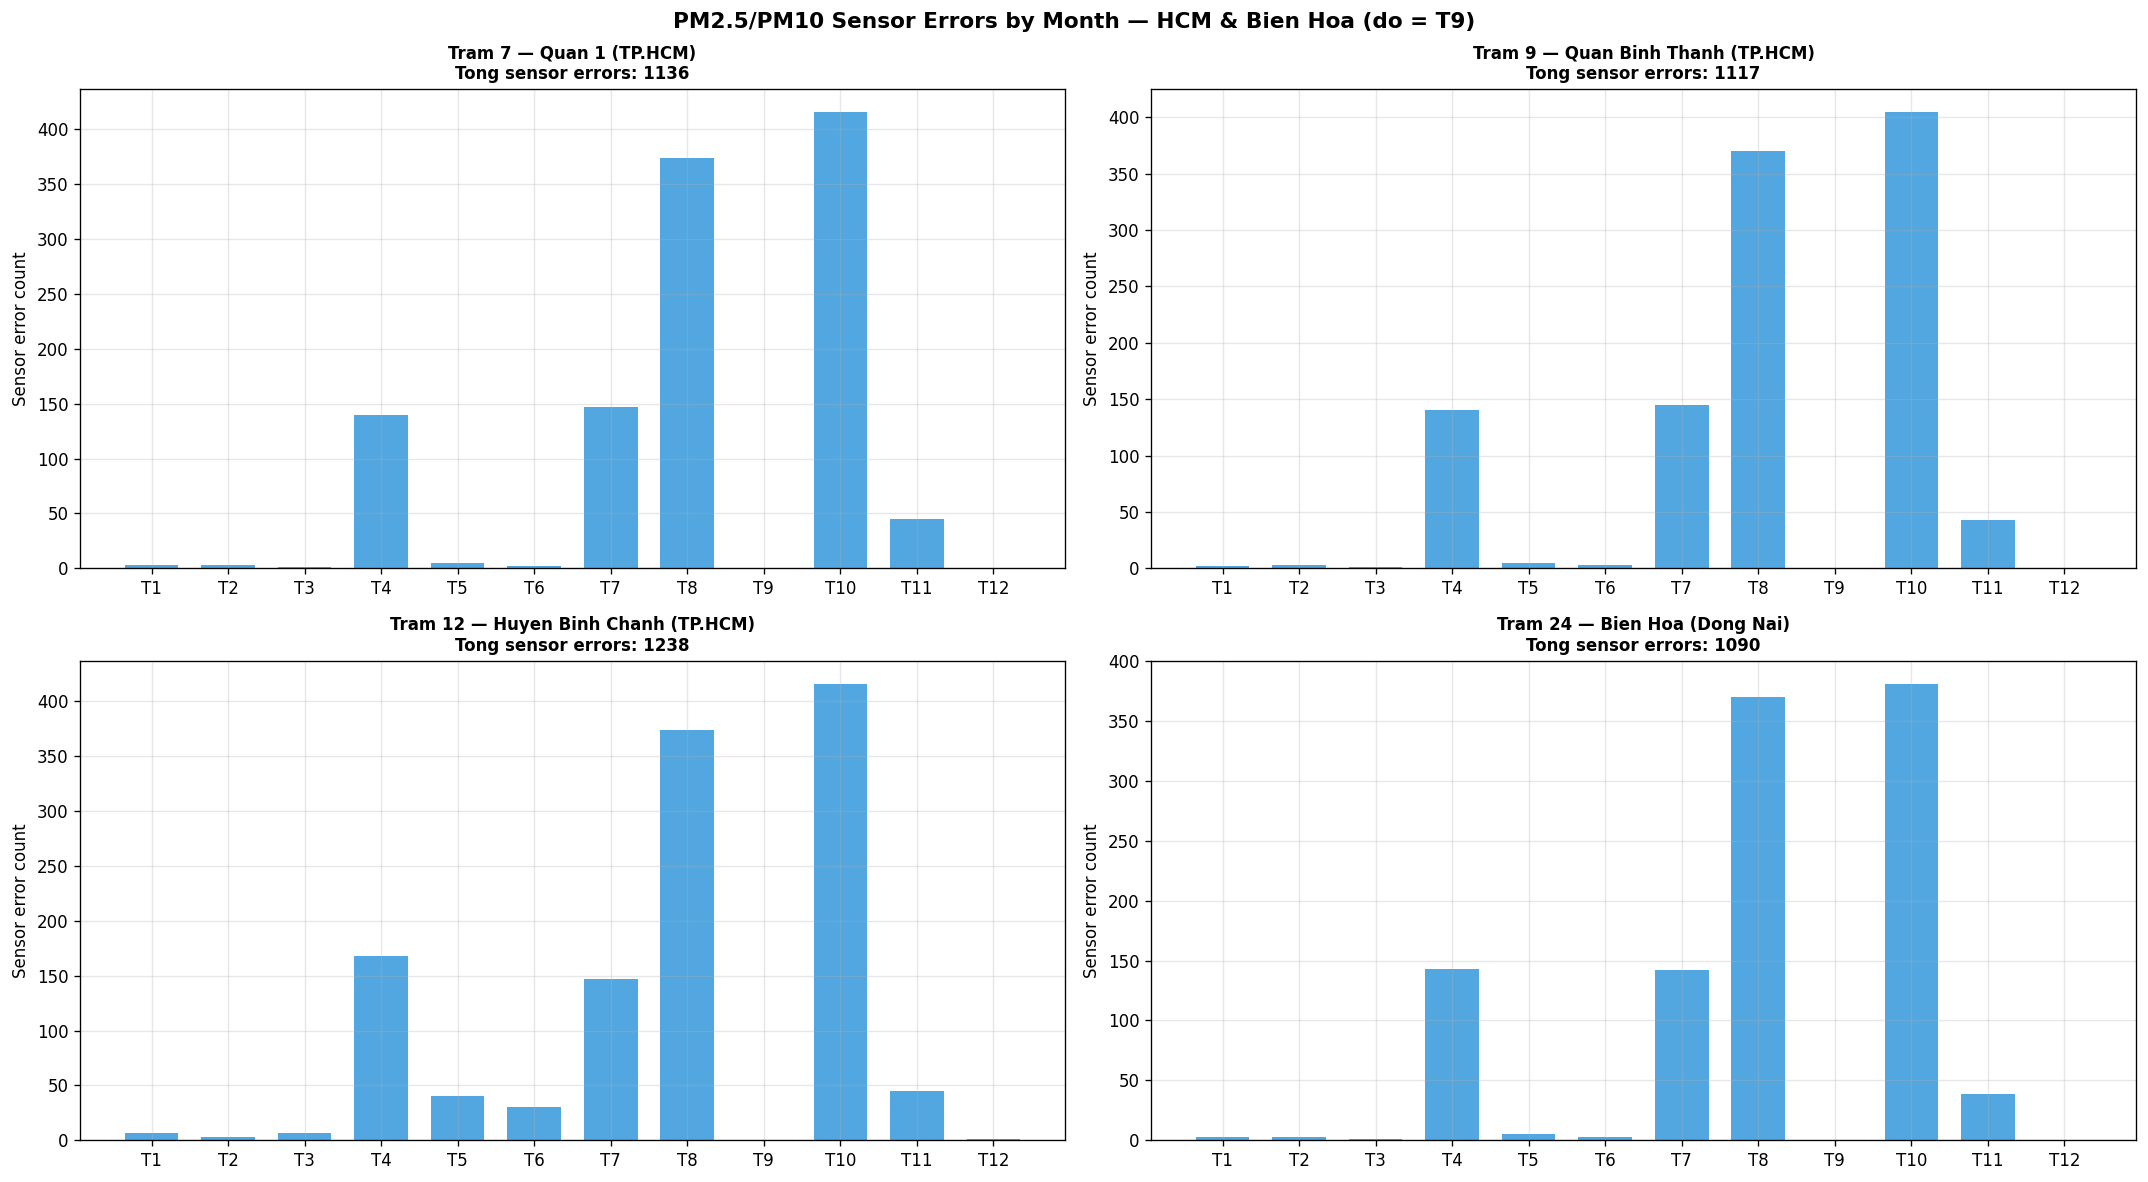

In [5]:
flag_rows = []
for df, meta in zip(station_dfs, station_meta):
    row = {'Station': f"{meta['station_id']}-{meta['district']}"}
    for flag in ['is_frozen', 'is_outlier', 'is_pm25_sensor_error']:
        if flag in df.columns:
            n = int(df[flag].sum())
            row[flag.replace('is_','')] = f"{n} ({n/len(df)*100:.1f}%)"
        else:
            row[flag.replace('is_','')] = 'N/A'
    row['total_rows'] = len(df)
    flag_rows.append(row)

flag_df = pd.DataFrame(flag_rows).set_index('Station')
display(flag_df)

# Bar chart sensor errors by month
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()
focus = [7, 9, 12, 24]
month_lbl = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']

for ax, sid in zip(axes, focus):
    df = get_df(sid)
    meta = station_meta[_sid_to_idx[sid]]
    if 'is_pm25_sensor_error' in df.columns:
        by_month = df.groupby(df.index.month)['is_pm25_sensor_error'].sum().reindex(range(1,13), fill_value=0)
        colors_bar = ['#E74C3C' if m == 9 else '#3498DB' for m in range(1, 13)]
        ax.bar(range(1, 13), by_month.values, color=colors_bar, width=0.7, alpha=0.85)
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(month_lbl)
        ax.set_title(f"Tram {sid} — {meta['district']} ({meta['province']})\n"
                     f"Tong sensor errors: {int(by_month.sum())}",
                     fontsize=10, fontweight='bold')
        ax.set_ylabel('Sensor error count')

fig.suptitle('PM2.5/PM10 Sensor Errors by Month — HCM & Bien Hoa (do = T9)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sensor_error_by_month.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Tương quan (Spearman) giữa tất cả features — Per Station
Dùng Spearman vì nhiều feature có phân phối lệch.

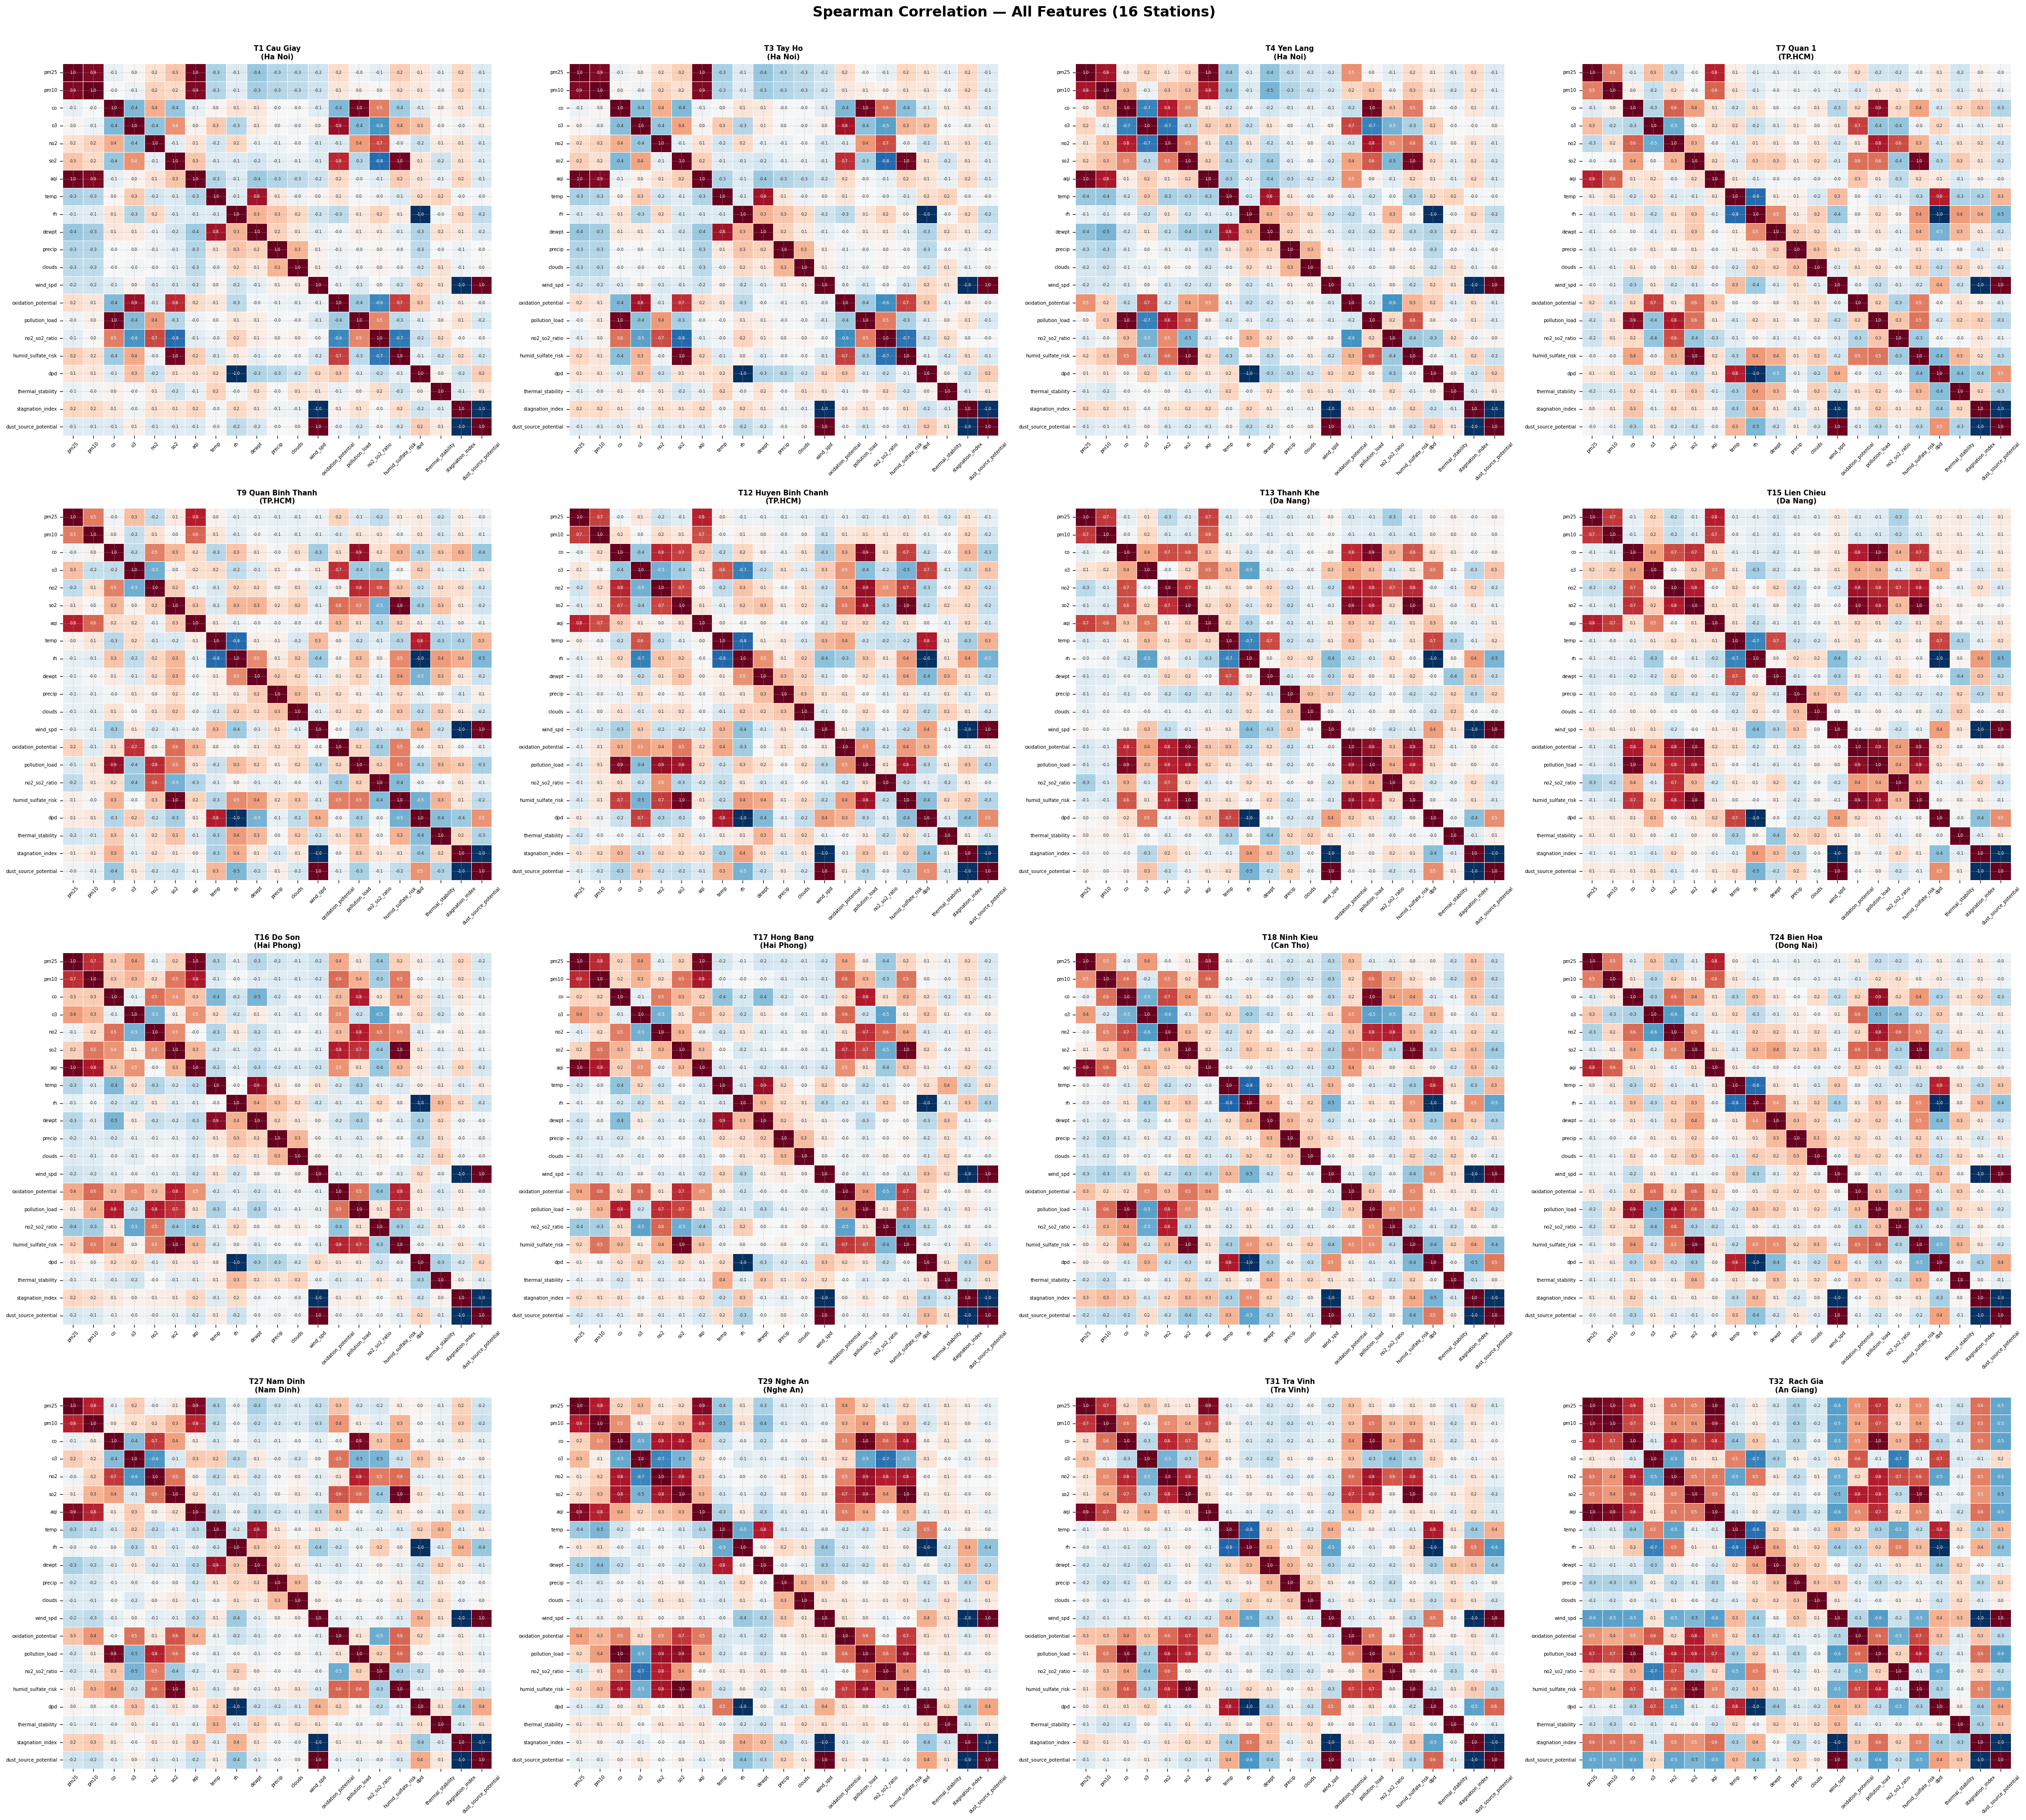

Saved: corr_all_features_16stations.png


In [6]:
CORR_COLS = [c for c in (RAW_POLL + RAW_WTH[:6] + ENG_FEATS) if c != 'wind_dir']
# wind_dir là circular — loại để tránh giả tương quan

fig, axes = plt.subplots(4, 4, figsize=(36, 32))
axes = axes.flatten()

for i, (df, meta) in enumerate(zip(station_dfs, station_meta)):
    ax = axes[i]
    cols_exist = [c for c in CORR_COLS if c in df.columns]
    corr = df[cols_exist].corr(method='spearman')

    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, ax=ax,
                annot=True, fmt='.1f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                linewidths=0.3, annot_kws={'size': 5},
                cbar=False)
    ax.set_title(f"T{meta['station_id']} {meta['district']}\n({meta['province']})",
                 fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=6)
    ax.tick_params(axis='y', rotation=0,  labelsize=6)

fig.suptitle('Spearman Correlation — All Features (16 Stations)',
             fontsize=18, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('corr_all_features_16stations.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: corr_all_features_16stations.png')

## 6. PM2.5 vs 8 Engineered Features — Scatter (4 trạm đại diện)

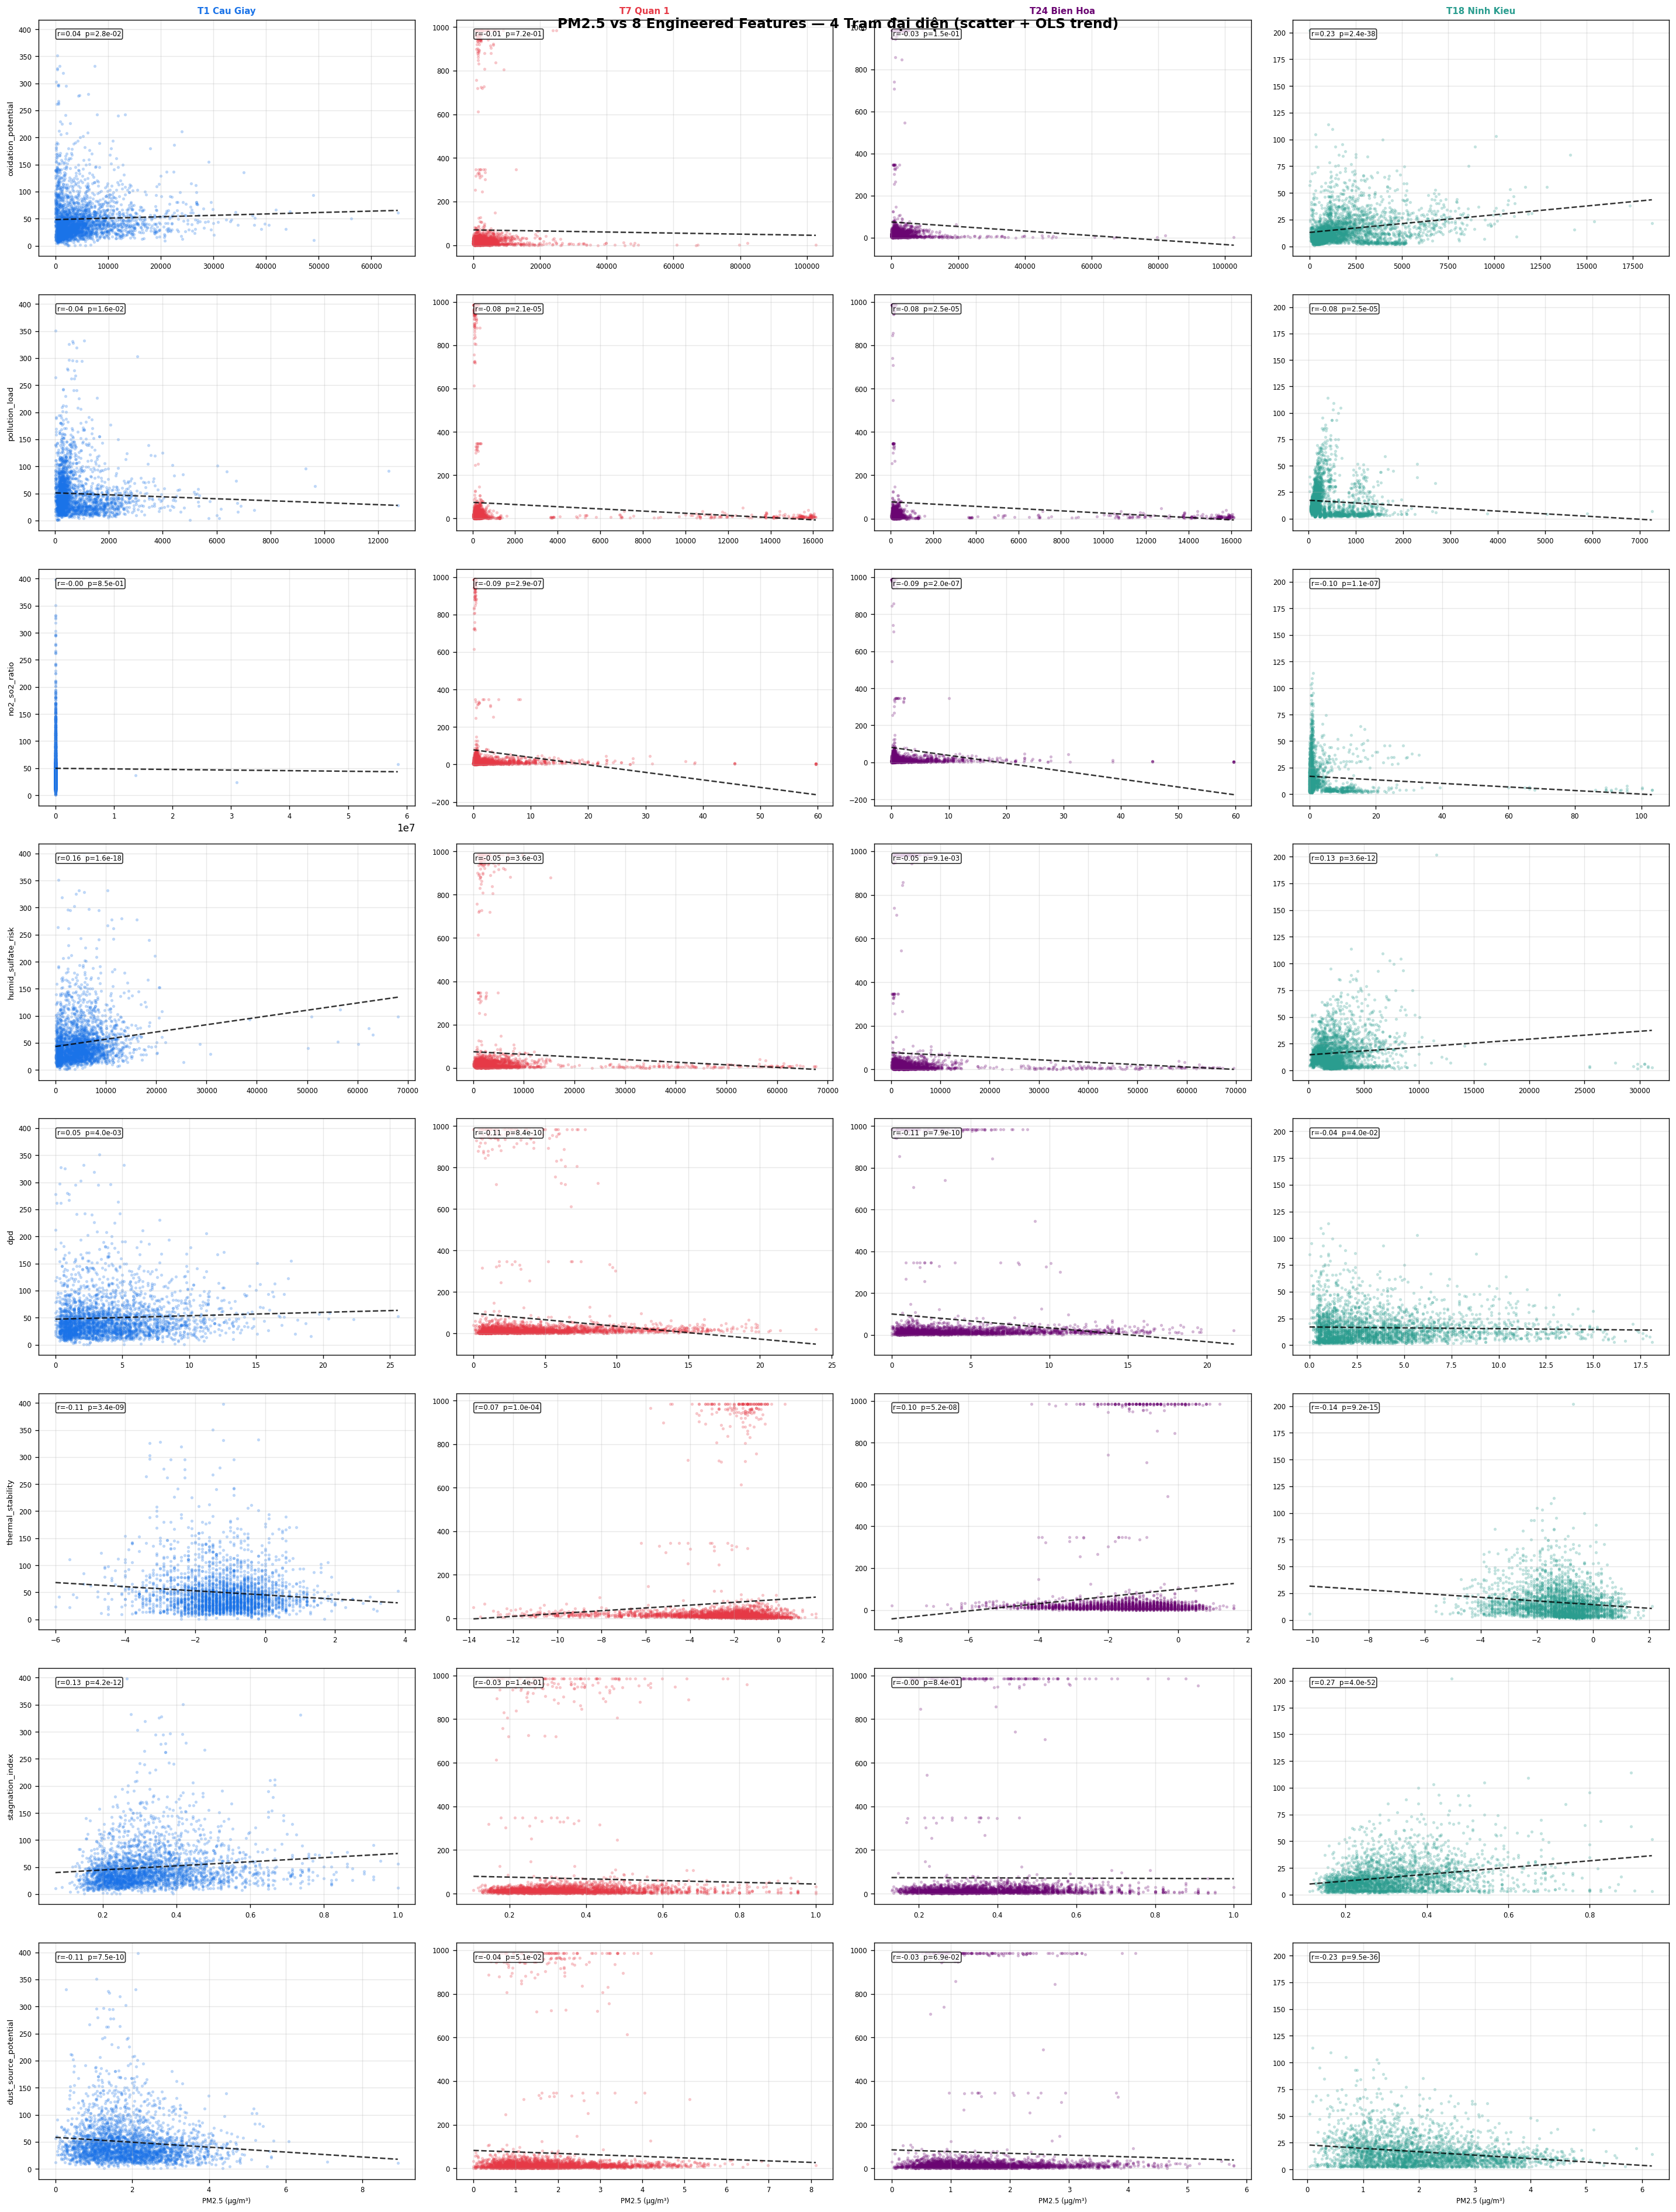

In [7]:
REPR_STATIONS = [1, 7, 24, 18]   # HN, HCM, Bien Hoa, Can Tho
REPR_COLORS  = ['#1A73E8', '#E63946', '#6A0572', '#2A9D8F']

fig, axes = plt.subplots(len(ENG_FEATS), len(REPR_STATIONS),
                          figsize=(24, len(ENG_FEATS)*4))

for col_idx, sid in enumerate(REPR_STATIONS):
    df   = get_df(sid)
    meta = station_meta[_sid_to_idx[sid]]
    color = REPR_COLORS[col_idx]

    for row_idx, feat in enumerate(ENG_FEATS):
        ax = axes[row_idx][col_idx]
        if feat not in df.columns or 'pm25' not in df.columns:
            ax.set_visible(False)
            continue

        sub = df[['pm25', feat]].dropna()
        # Subsample nếu quá nhiều điểm
        if len(sub) > 3000:
            sub = sub.sample(3000, random_state=42)

        ax.scatter(sub[feat], sub['pm25'], alpha=0.2, s=5, color=color)

        # Trend line
        try:
            slope, intercept, r, p, _ = stats.linregress(sub[feat], sub['pm25'])
            x_line = np.linspace(sub[feat].min(), sub[feat].max(), 100)
            ax.plot(x_line, slope * x_line + intercept,
                    color='black', lw=1.5, ls='--', alpha=0.8)
            ax.text(0.05, 0.93, f'r={r:.2f}  p={p:.1e}',
                    transform=ax.transAxes, fontsize=7,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
        except Exception:
            pass

        if row_idx == 0:
            ax.set_title(f"T{sid} {meta['district']}", fontsize=9, fontweight='bold', color=color)
        if col_idx == 0:
            ax.set_ylabel(feat, fontsize=8)
        ax.set_xlabel('PM2.5 (µg/m³)' if row_idx == len(ENG_FEATS)-1 else '', fontsize=7)
        ax.tick_params(labelsize=7)

fig.suptitle('PM2.5 vs 8 Engineered Features — 4 Trạm đại diện (scatter + OLS trend)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_pm25_vs_eng_features.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. So sánh cross-station — 8 Engineered Features (Boxplot)

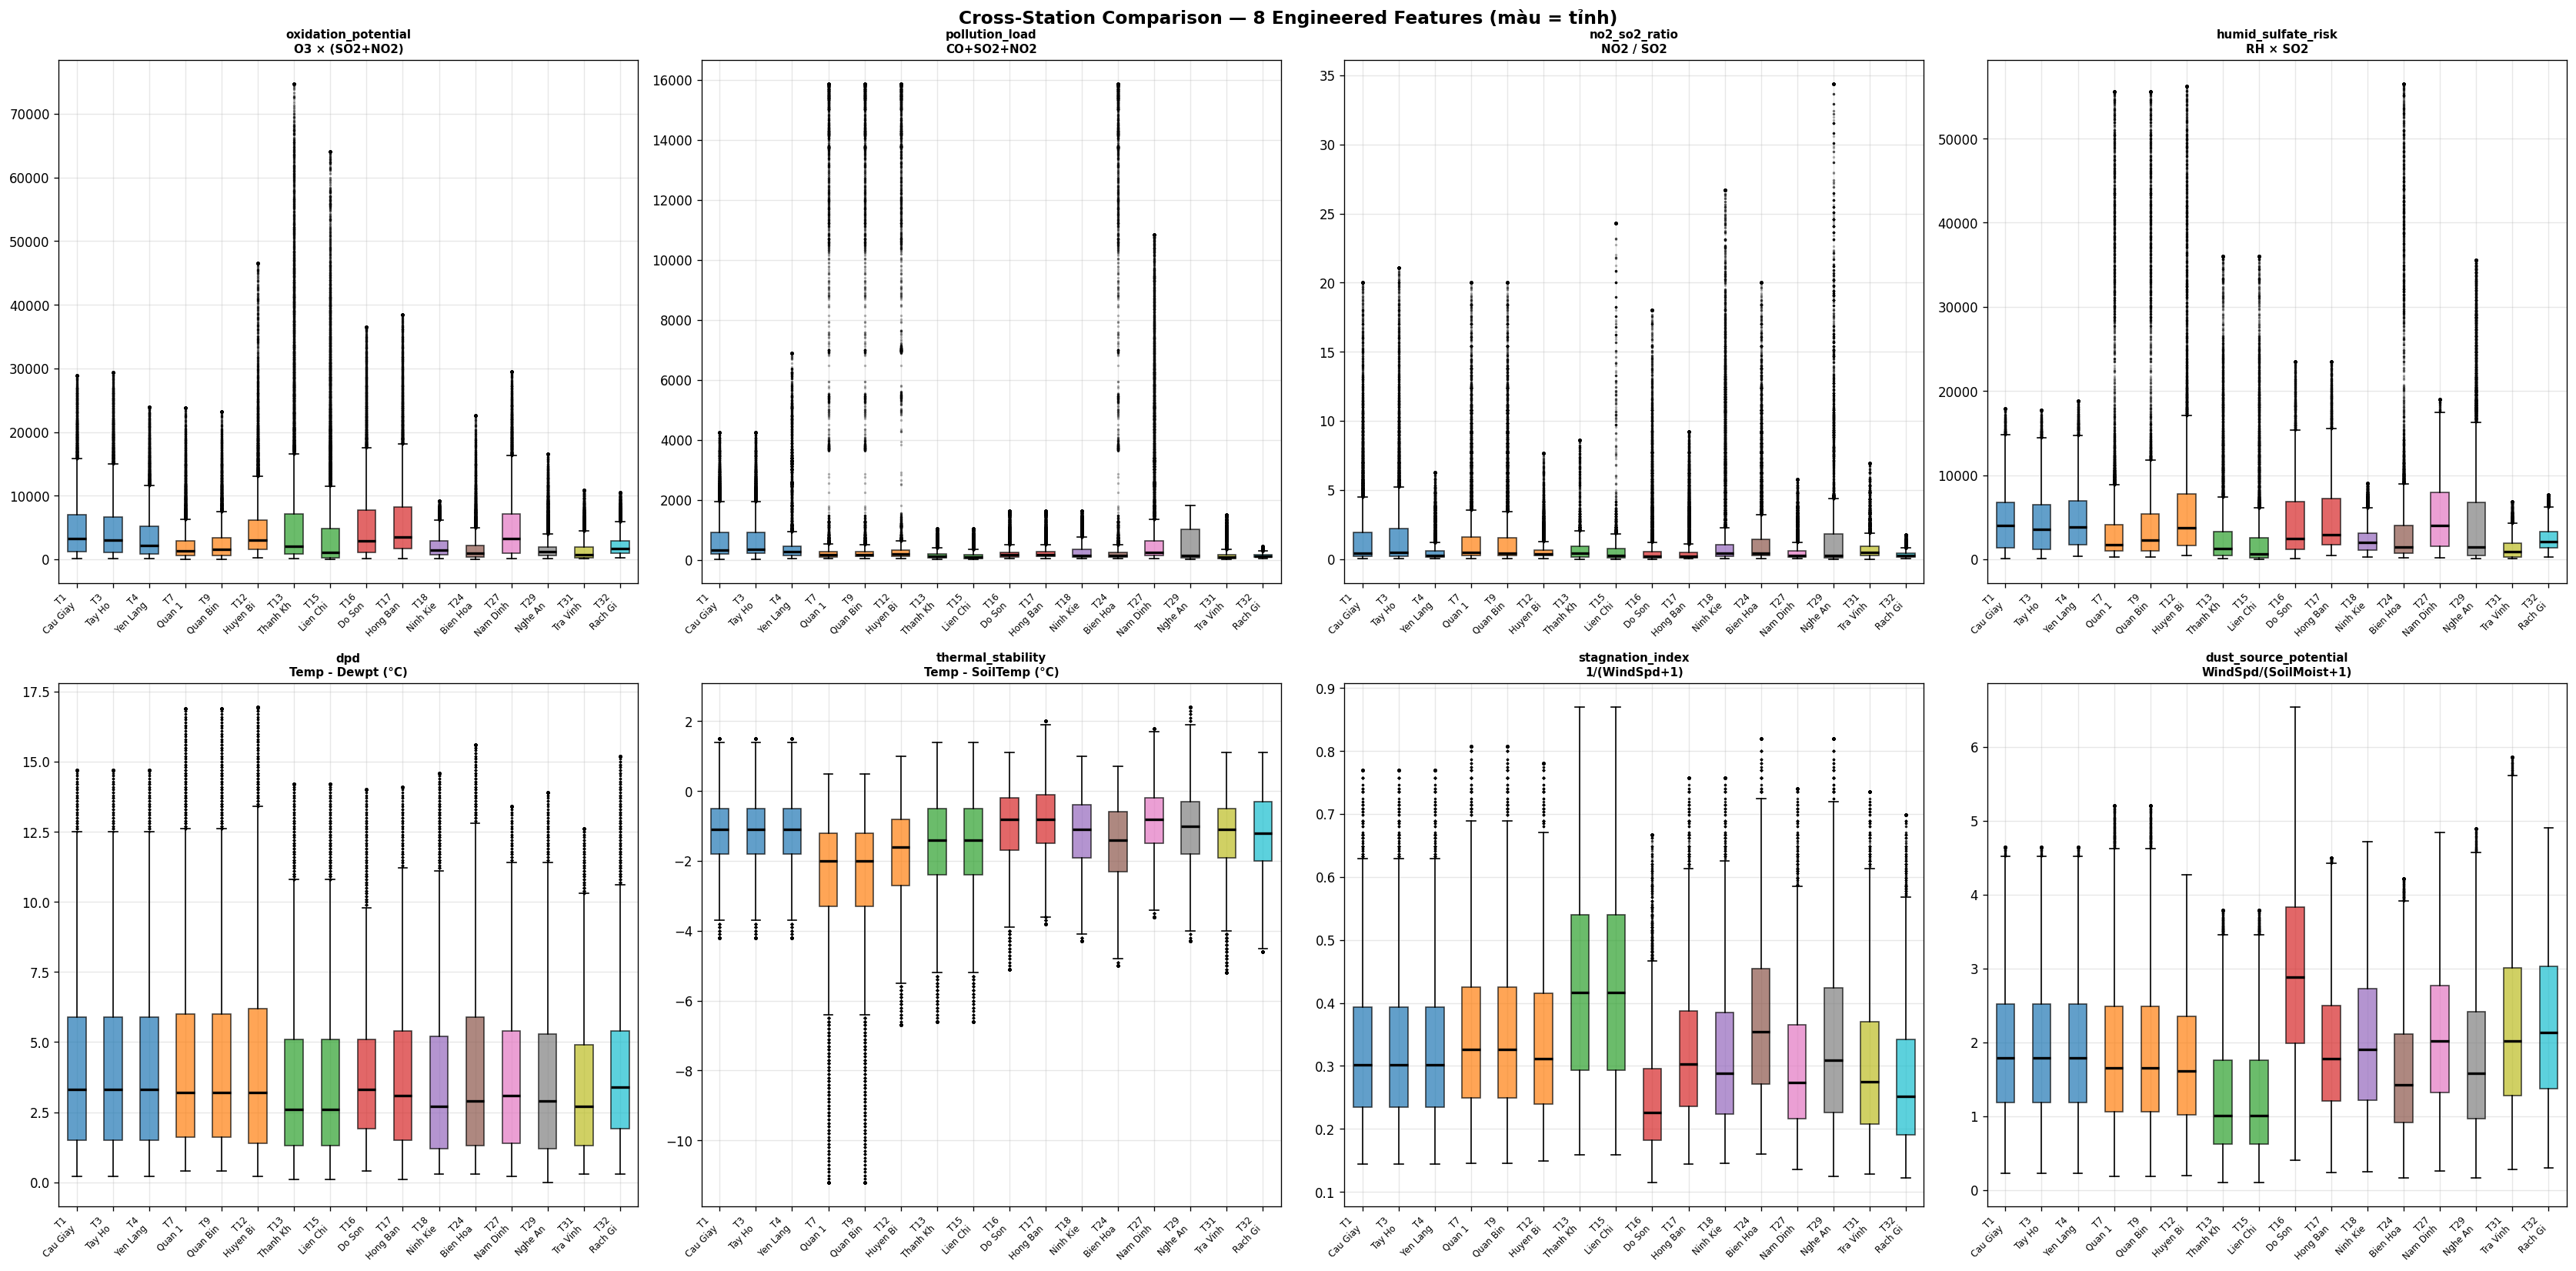

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(28, 14))
axes = axes.flatten()

station_labels = [f"T{m['station_id']}\n{m['district'][:8]}" for m in station_meta]

for i, feat in enumerate(ENG_FEATS):
    ax = axes[i]
    data_by_station = []
    for df in station_dfs:
        if feat in df.columns:
            vals = df[feat].dropna()
            q1, q99 = vals.quantile(0.01), vals.quantile(0.99)
            data_by_station.append(vals.clip(q1, q99).values)
        else:
            data_by_station.append(np.array([]))

    bp = ax.boxplot(data_by_station, patch_artist=True, notch=False,
                    medianprops=dict(color='black', lw=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))

    # Tô màu theo province
    prov_list = [m['province'] for m in station_meta]
    unique_provs = list(dict.fromkeys(prov_list))
    prov_color_map = {p: plt.cm.tab10(j/len(unique_provs)) for j, p in enumerate(unique_provs)}
    for patch, prov in zip(bp['boxes'], prov_list):
        patch.set_facecolor(prov_color_map[prov]); patch.set_alpha(0.7)

    ax.set_xticks(range(1, len(station_labels)+1))
    ax.set_xticklabels(station_labels, rotation=45, ha='right', fontsize=7)
    ax.set_title(f'{feat}\n{ENG_INFO[feat]}', fontsize=9, fontweight='bold')

fig.suptitle('Cross-Station Comparison — 8 Engineered Features (màu = tỉnh)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('crossstation_eng_features_boxplot.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. PM2.5 Distribution BEFORE vs AFTER Sensor Error Removal

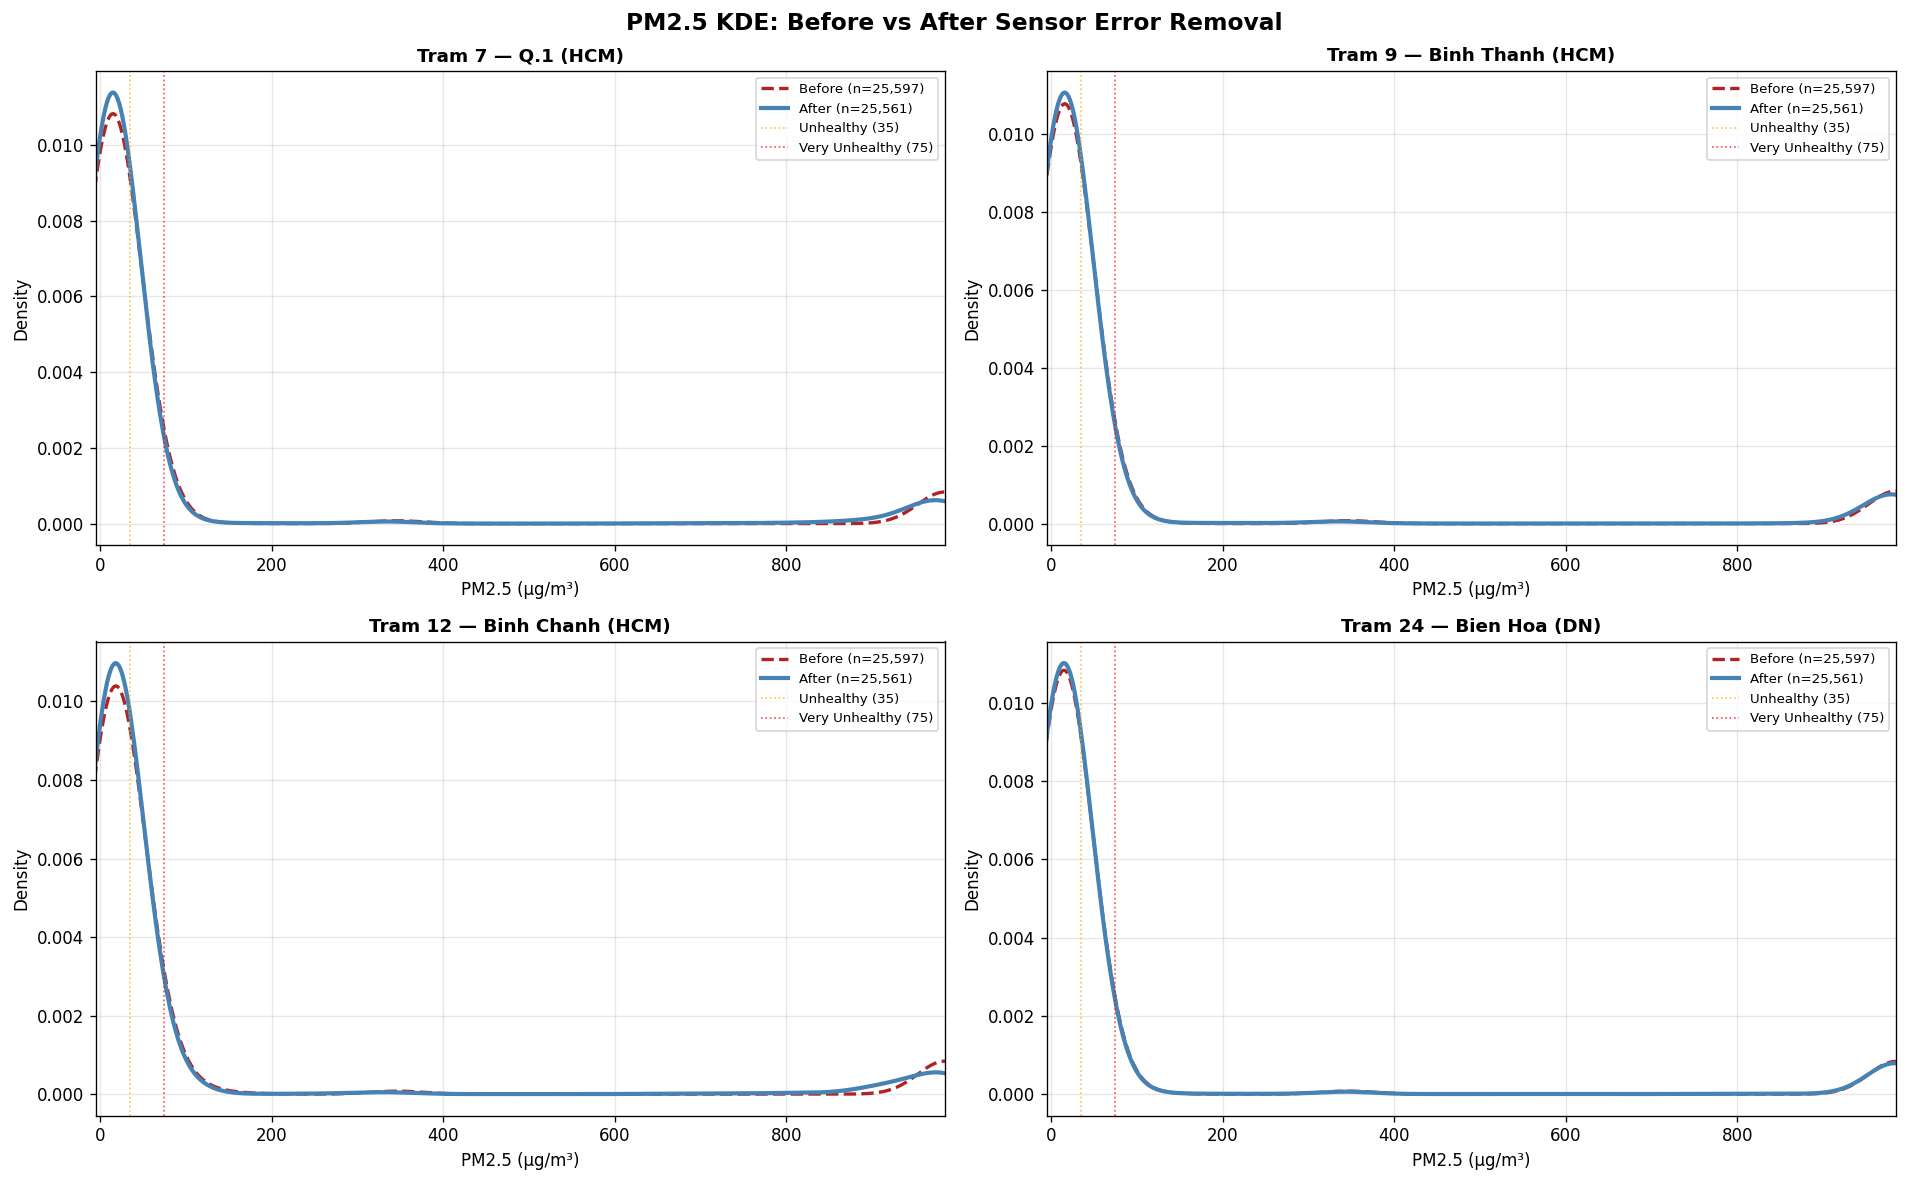

In [9]:
FOCUS = {7:'Q.1 (HCM)', 9:'Binh Thanh (HCM)', 12:'Binh Chanh (HCM)', 24:'Bien Hoa (DN)'}
RAW_DIR = 'data/raw/air'

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (sid, lbl) in zip(axes, FOCUS.items()):
    # Raw (before)
    raw = pd.read_csv(f'{RAW_DIR}/air_{sid}.csv')[['pm25', 'pm10']].dropna()
    # Clean (after)
    clean = get_df(sid)[['pm25']].dropna()

    q99 = raw['pm25'].quantile(0.99)
    raw_clipped   = raw['pm25'].clip(0, q99)
    clean_clipped = clean['pm25'].clip(0, q99)

    raw_clipped.plot.kde(ax=ax, color='firebrick', lw=2, ls='--', label=f'Before (n={len(raw):,})')
    clean_clipped.plot.kde(ax=ax, color='steelblue', lw=2.5, label=f'After (n={len(clean):,})')

    ax.axvline(35,  color='orange', lw=1, ls=':', alpha=0.7, label='Unhealthy (35)')
    ax.axvline(75,  color='red',    lw=1, ls=':', alpha=0.7, label='Very Unhealthy (75)')
    ax.set_title(f'Tram {sid} — {lbl}', fontsize=11, fontweight='bold')
    ax.set_xlabel('PM2.5 (µg/m³)'); ax.legend(fontsize=8)
    ax.set_xlim([-5, q99])

fig.suptitle('PM2.5 KDE: Before vs After Sensor Error Removal',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pm25_before_after_sensor_error.png', dpi=120, bbox_inches='tight')
plt.show()